# Red Wine Qualite Dataset:

Vamos a usar el dataset que se encuentra en:

https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009

Que se usa para construir modelos que predigan si un determinado vino es de buena calidad o no.

Importamos las librerías

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Leemos los datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SAA/data_folder/winequality-red.csv', sep=';')

# Preparación de datos

Problemas con los que nos podemos encontrar:

>

1.   Valores Nan
2.   Valores categóricos

## Comprensión y visualización de datos

A partir de la información subministrada por ***df.info()***: ¿Qué variables deben ser modificadas? ¿Porque razón? ¿ Qué métodos podemos emplear?



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# Si queremos ver únicamente los primeros valores que hay en una base de datos ejecutamos:
df.head()
# Recordemos la importancia de visualizar la tabla, para poder ver de una manera clara como está estructurada la información

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# El atributo objetivo es quality
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [ ]:
df['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [ ]:
# ¿Cuántas filas y columnas tiene nuestra base de datos?
print("Filas, columnas: " + str(df.shape))

Filas, columnas: (1599, 12)


## Limpieza de datos

En principio los datos a simple vista parecen que están correctos. Aquí habría que explorar las distintas variables como ya hemos visto.

In [ ]:
#Vamos a ver si hay valores nulos
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


#Transformaciones

## Discretización de datos y creación de atributos

<Axes: xlabel='quality', ylabel='count'>

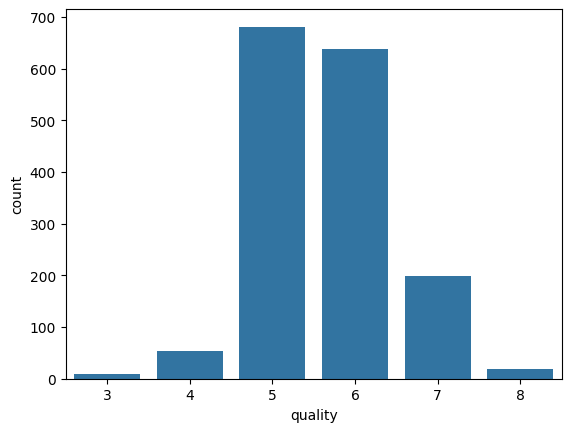

In [ ]:
sns.countplot(x='quality', data=df)

In [ ]:
# Vamos a considerar que los vinos con valores 1, 2 y 3 son malos (valor 1),
# con valores 4, 5, y 6 tienen una calidad media (valor 2),
# con valores 7 y 8 son buenos (valor 3) y aquellos con 9 y 10 son excelentes (valor 4)
df['calidad'] = df['quality']
df.loc[df['quality'] <= 3, 'calidad'] = 1
df.loc[(df['quality'] >= 4) & (df['quality'] <= 6), 'calidad'] = 2
df.loc[(df['quality'] >= 7) & (df['quality'] <= 8), 'calidad'] = 3
df.loc[(df['quality'] >= 9), 'calidad'] = 4

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'calidad'],
      dtype='object')

In [ ]:
df['calidad'].unique()

array([2, 3, 1])

In [ ]:
df['calidad'].value_counts()

,count
calidad,
2,1372
3,217
1,10


##Outliers

<Axes: xlabel='quality', ylabel='fixed acidity'>

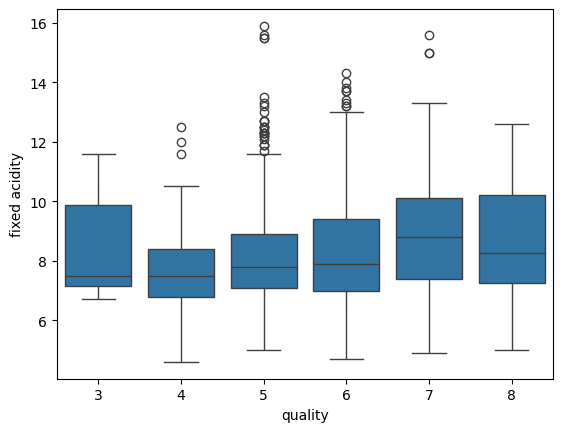

In [ ]:
# Para buscar Outliers
# Como la variable objetivo es quality, vamos a ver la relación entre dicha variable y el resto
sns.boxplot(x='quality', y='fixed acidity', data = df)

<Axes: xlabel='quality', ylabel='volatile acidity'>

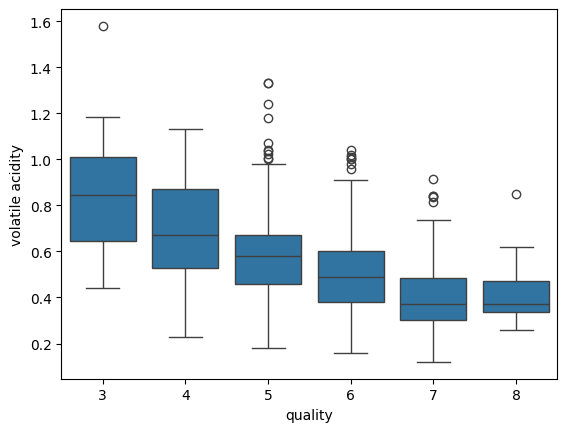

In [ ]:
sns.boxplot(x='quality', y='volatile acidity', data = df)

<Axes: xlabel='quality', ylabel='citric acid'>

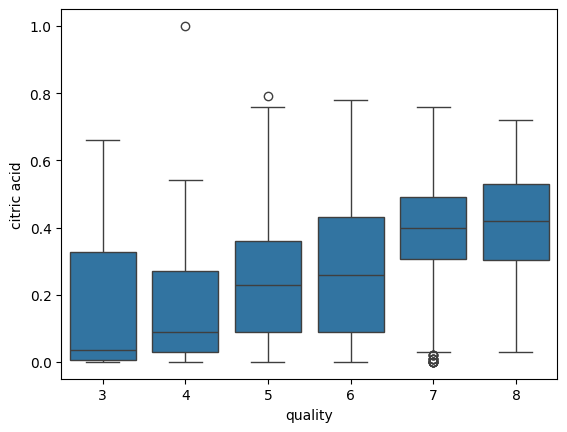

In [ ]:
sns.boxplot(x='quality', y='citric acid', data = df)

<Axes: xlabel='quality', ylabel='residual sugar'>

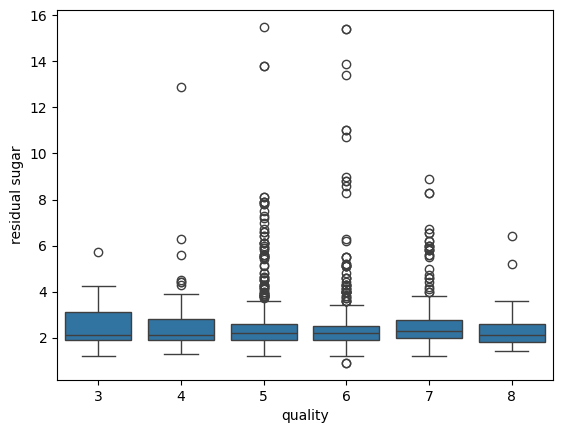

In [ ]:
sns.boxplot(x='quality', y='residual sugar', data = df)

<Axes: xlabel='quality', ylabel='chlorides'>

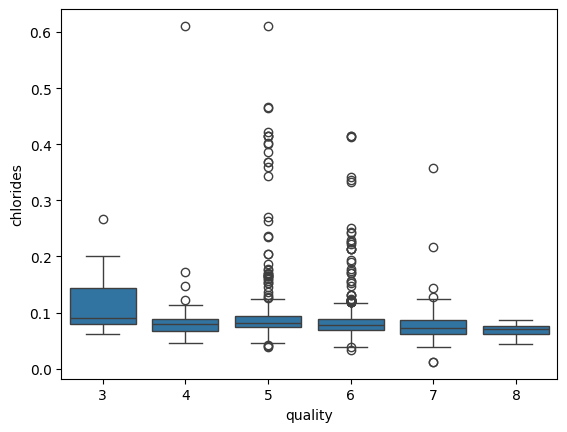

In [ ]:
sns.boxplot(x='quality', y='chlorides', data = df)

<Axes: xlabel='quality', ylabel='free sulfur dioxide'>

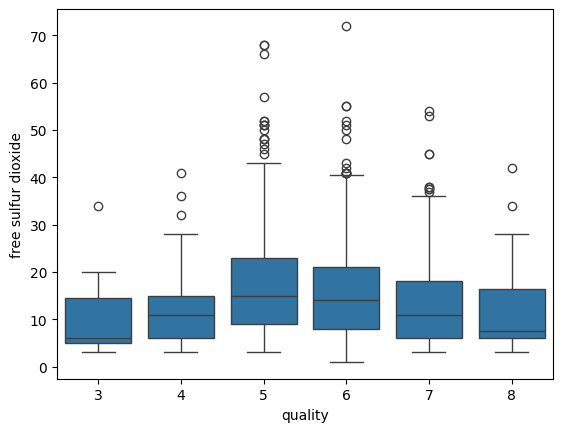

In [ ]:
sns.boxplot(x='quality', y='free sulfur dioxide', data = df)

<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

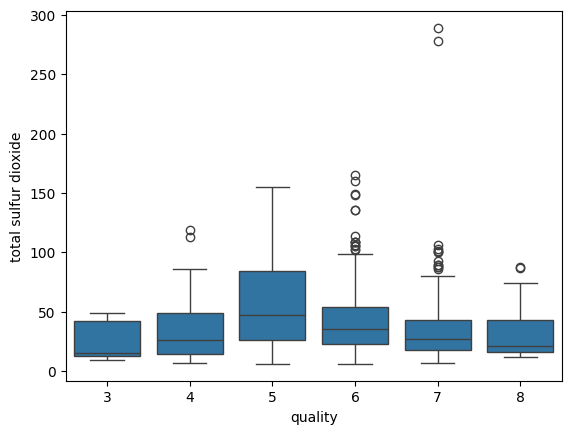

In [ ]:
sns.boxplot(x='quality', y='total sulfur dioxide', data = df)

<Axes: xlabel='quality', ylabel='density'>

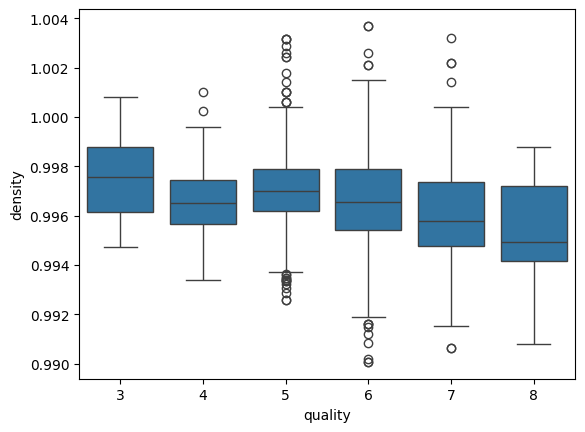

In [ ]:
sns.boxplot(x='quality', y='density', data = df)

<Axes: xlabel='quality', ylabel='pH'>

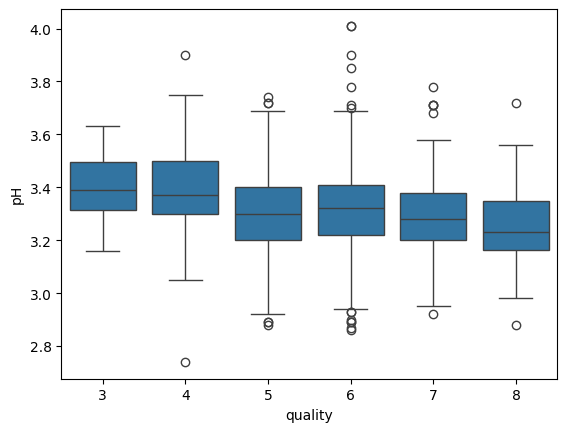

In [ ]:
sns.boxplot(x='quality', y='pH', data = df)

<Axes: xlabel='quality', ylabel='sulphates'>

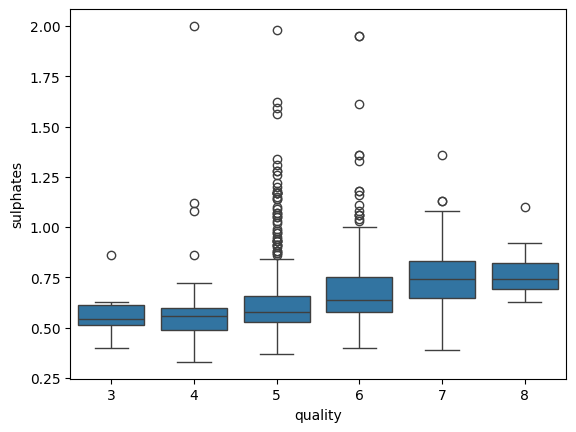

In [ ]:
sns.boxplot(x='quality', y='sulphates', data = df)

<Axes: xlabel='quality', ylabel='alcohol'>

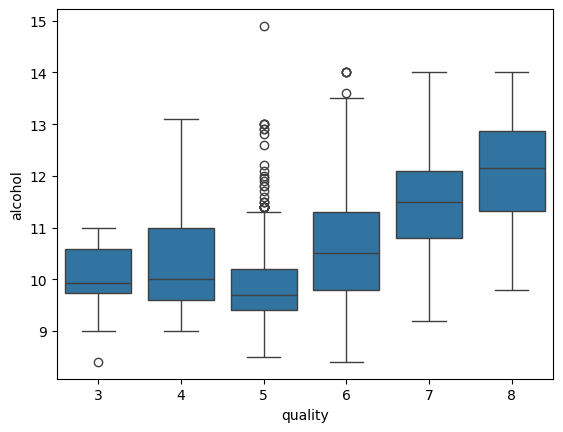

In [ ]:
sns.boxplot(x='quality', y='alcohol', data = df)

Se ve que hay bastantes outliers en algunas columnas. Vamos a seguir mirando

In [ ]:
# Estadísticas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,calidad
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,2.129456
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.353954
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,1.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,2.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,2.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,2.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,3.000000


¿Qué vemos?

*   'fixed acidiy', 'volatile acidity': apenas hay diferencia entre el 25% y el 50% -> distribución no uniforme que puede explicar el gran número de outliers
*   'citric acid': si que parece que está uniformemente distribuido.
*   'residual sugar': min -> 0.9, max -> 15. Demasiada diferencia que también puede explicar el gran número de outliers
*   'chlorides', 'free sulfur dioxide', 'total suflur dioxide': misma expliación.

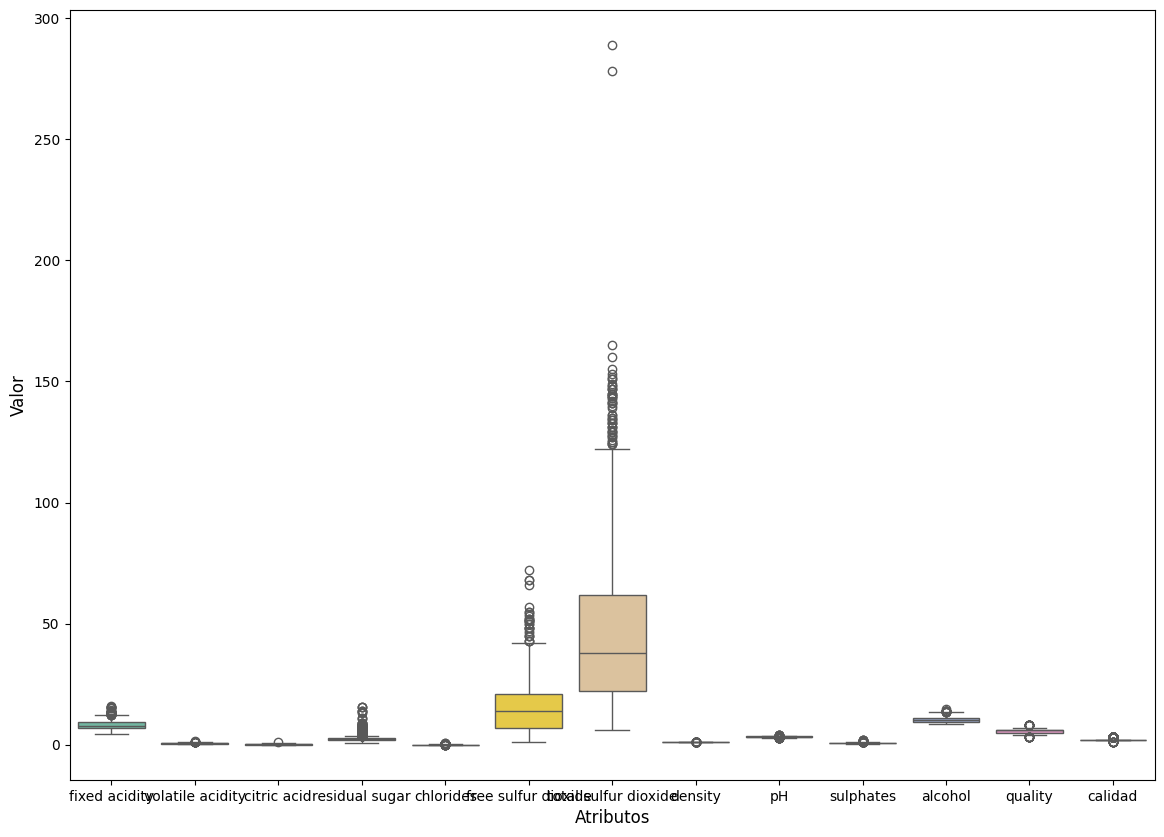

In [ ]:
# Vamos a ver todas las variables

def crear_boxplots(df, columnas):
    plt.figure(figsize=(14, 10))

    sns.boxplot(data=df[columnas], palette='Set2')
    plt.xlabel('Atributos', fontsize=12)
    plt.ylabel('Valor', fontsize=12)
    plt.show()

crear_boxplots(df, df.columns)


In [ ]:
# Una forma de actuar es eliminar los outliers

df_sin_outliers = df.drop(columns=['quality', 'calidad'], axis=1)
for columna in df_sin_outliers.columns:
    Q1 = df_sin_outliers[columna].quantile(0.25)
    Q3 = df_sin_outliers[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definimos los límites inferiores y superiores
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtramos el DataFrame eliminando los outliers
    df_sin_outliers[columna] = df_sin_outliers[columna][((df_sin_outliers[columna] > limite_inferior) & (df_sin_outliers[columna] < limite_superior))]


#Normalización

In [ ]:
# Vamos a normalizar por la diferencia, que intenta compensar el efecto de la distancia del valor que tratamos con respecto al máximo de los valores
def normalize (wine):
  result = wine.copy()

  for feature_name in wine.columns:
    max_value = wine[feature_name].max()
    min_value = wine[feature_name].min()
    result[feature_name] = (wine[feature_name] - min_value) / (max_value - min_value)
  return result

df_normalizado = normalize(df_sin_outliers)

df_normalizado.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.363636,0.651685,0.000000,0.363636,0.448718,0.25,0.243478,0.630058,0.773333,0.348485,0.20
1,0.415584,0.853933,0.000000,0.618182,0.730769,0.60,0.530435,0.514451,0.360000,0.530303,0.28
2,0.415584,0.719101,0.050633,0.509091,0.653846,0.35,0.417391,0.537572,0.440000,0.484848,0.28
3,0.857143,0.179775,0.708861,0.363636,0.435897,0.40,0.469565,0.653179,0.306667,0.378788,0.28
4,0.363636,0.651685,0.000000,0.363636,0.448718,0.25,0.243478,0.630058,0.773333,0.348485,0.20


In [ ]:
df_normalizado.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1550.000000,1580.000000,1598.000000,1444.000000,1487.000000,1566.000000,1541.000000,1554.000000,1564.000000,1540.000000,1585.000000
mean,0.462673,0.450060,0.342430,0.465399,0.484050,0.353368,0.320379,0.506888,0.505030,0.464266,0.398484
std,0.196569,0.187170,0.245577,0.163324,0.190579,0.229009,0.234928,0.192683,0.187331,0.183278,0.203750
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.324675,0.303371,0.113924,0.363636,0.371795,0.150000,0.130435,0.378035,0.373333,0.333333,0.220000
50%,0.428571,0.449438,0.329114,0.436364,0.474359,0.300000,0.269565,0.508092,0.506667,0.439394,0.340000
75%,0.584416,0.573034,0.531646,0.581818,0.589744,0.500000,0.452174,0.630058,0.626667,0.575758,0.520000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


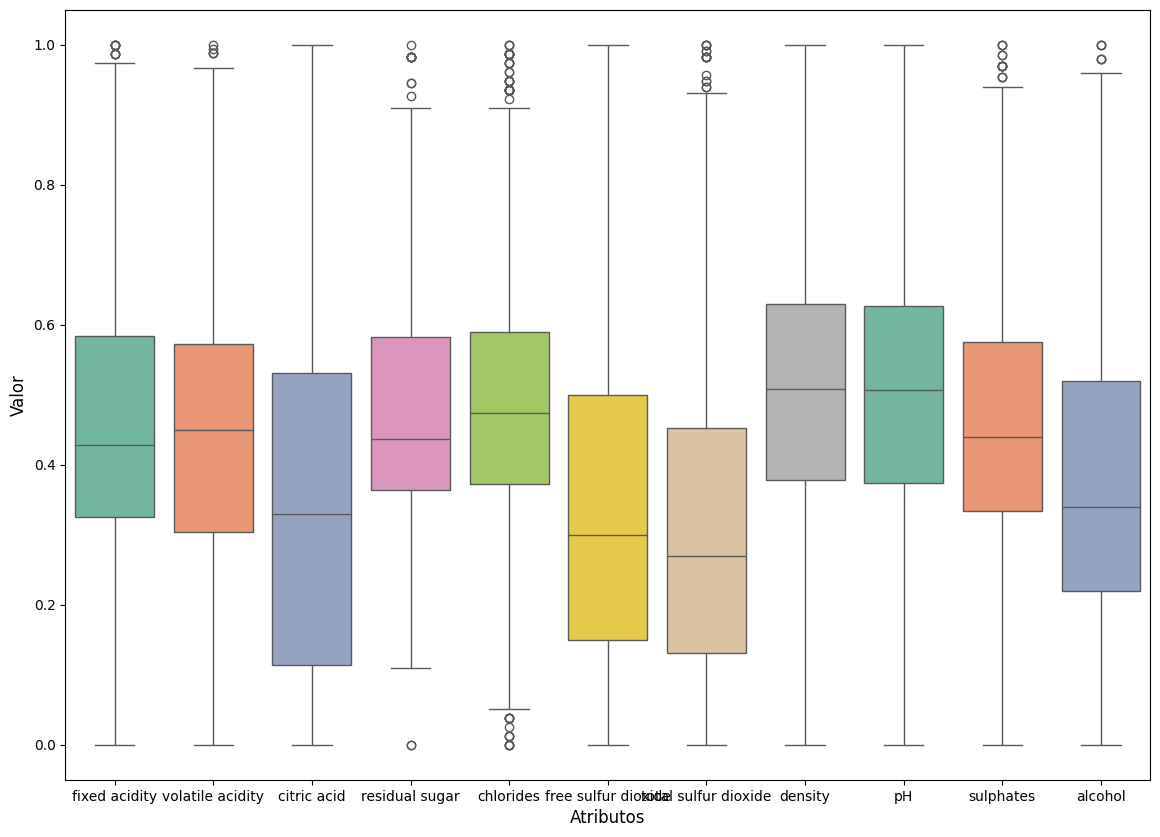

In [ ]:
crear_boxplots(df_normalizado, df_normalizado.columns)

Normalizando los datos hemos conseguido igualar el rango de los mismos.

# Discretización

Discretizar los datos es el proceso de transformar variables numéricas continuas de tu dataset en variables categóricas.

La idea consiste en dividir el intervalo de valores que puede tomar una característica (la característica que queremos discretizar) en varios segmentos contiguos.

In [ ]:
df_disc = df.drop(columns=['quality', 'calidad'], axis=1)
for columna in df_disc.columns:
    df_disc[columna] = pd.cut(df_disc[columna], bins=5, labels=[1,2,3,4,5])

df_disc.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,2,2,1,1,1,1,1,3,4,1,1
1,2,3,1,1,1,2,2,3,2,2,2
2,2,3,1,1,1,1,1,3,3,1,2
3,3,1,3,1,1,2,1,3,2,1,2
4,2,2,1,1,1,1,1,3,4,1,1
